# 03 — Model Training & Backtesting

**Goal:** Train position-specific Ridge regression models and validate them.

Steps:
1. Train FantasyProjectionModel on YoY pairs (2020→2021 through 2023→2024)
2. Review CV R² and alpha grid search results per position
3. Plot feature importances
4. Backtest: hold out 2024, predict it, compare to actuals
5. Fit and plot aging curves
6. Residual analysis: who did the model miss on and why?

In [2]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TRAINING_SEASONS, POSITIONS, POSITION_FEATURES
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.projection import FantasyProjectionModel
from models.age_curves import plot_age_curves, fit_age_curves

print('Imports OK')

Imports OK


## 1. Load Feature Matrix

In [3]:
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
yoy = build_yoy_pairs(feature_matrix)
print(f'Feature matrix: {feature_matrix.shape}')
print(f'YoY pairs: {len(yoy)}')

Loading feature matrix from cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Feature matrix: (1452, 101)
YoY pairs: 814


## 2. Train Models

In [4]:
model = FantasyProjectionModel(age_adjust=True)
model.train(yoy)

Fitting age curves...
  QB: n=128, features=9, alpha=10.0, CV MAE=3.18
  RB: n=232, features=12, alpha=10.0, CV MAE=3.31
  WR: n=329, features=13, alpha=10.0, CV MAE=2.72
  TE: n=125, features=10, alpha=10.0, CV MAE=2.08


In [5]:
# Best alpha per position
print('Best regularization alpha per position:')
for pos, alpha in model._best_alphas.items():
    print(f'  {pos}: alpha={alpha}')

Best regularization alpha per position:
  QB: alpha=10.0
  RB: alpha=10.0
  WR: alpha=10.0
  TE: alpha=10.0


## 3. Feature Importances

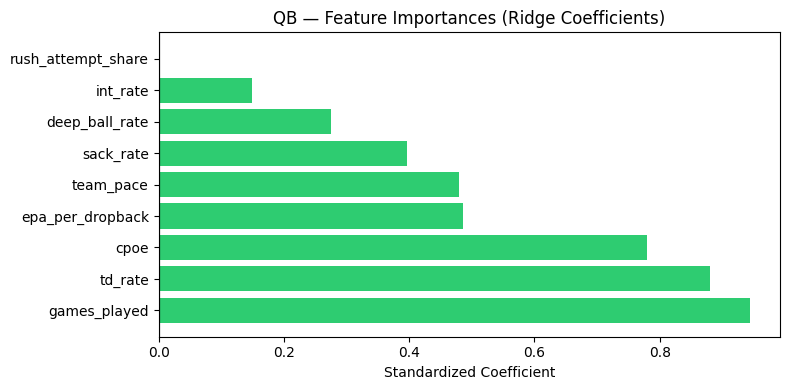


QB top factors:
         feature  coefficient  abs_coefficient
    games_played     0.944765         0.944765
         td_rate     0.879801         0.879801
            cpoe     0.779775         0.779775
epa_per_dropback     0.486149         0.486149
       team_pace     0.479589         0.479589


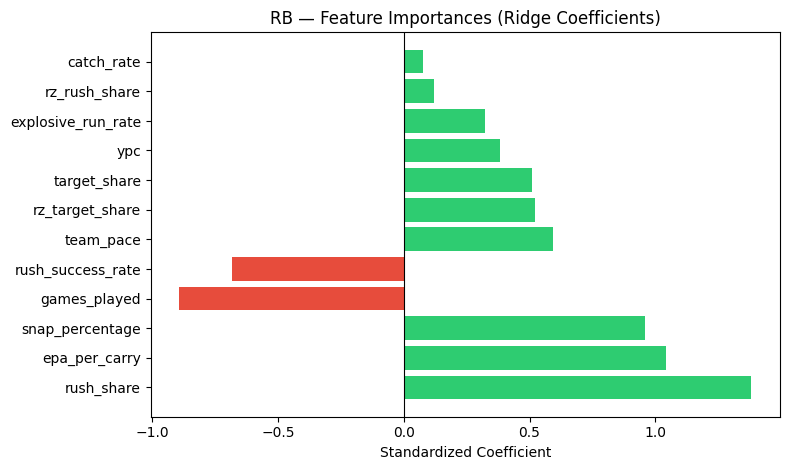


RB top factors:
          feature  coefficient  abs_coefficient
       rush_share     1.382392         1.382392
    epa_per_carry     1.042778         1.042778
  snap_percentage     0.960610         0.960610
     games_played    -0.892613         0.892613
rush_success_rate    -0.684081         0.684081


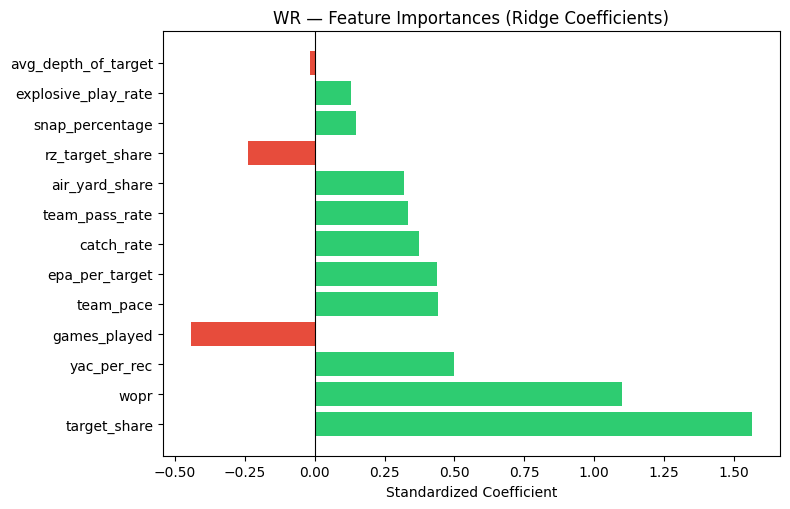


WR top factors:
     feature  coefficient  abs_coefficient
target_share     1.564705         1.564705
        wopr     1.099158         1.099158
 yac_per_rec     0.499281         0.499281
games_played    -0.442315         0.442315
   team_pace     0.441053         0.441053


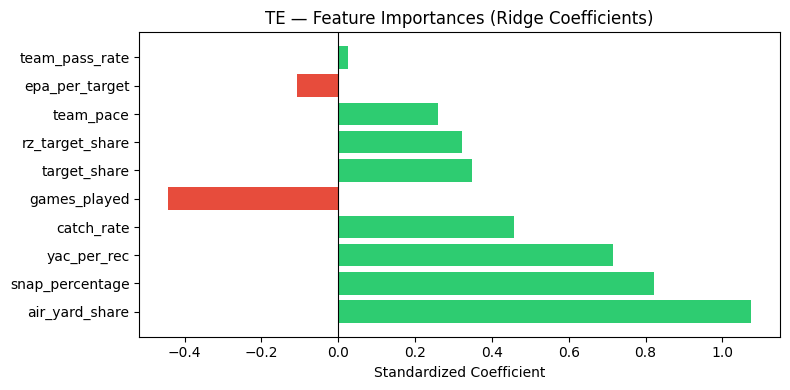


TE top factors:
        feature  coefficient  abs_coefficient
 air_yard_share     1.074261         1.074261
snap_percentage     0.820884         0.820884
    yac_per_rec     0.714351         0.714351
     catch_rate     0.458490         0.458490
   games_played    -0.442171         0.442171


In [6]:
for pos in POSITIONS:
    if pos not in model._models:
        continue
    try:
        importance = model.feature_importance(pos)
        
        fig, ax = plt.subplots(figsize=(8, max(4, len(importance) * 0.4)))
        colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in importance['coefficient']]
        ax.barh(importance['feature'], importance['coefficient'], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{pos} — Feature Importances (Ridge Coefficients)', fontsize=12)
        ax.set_xlabel('Standardized Coefficient')
        plt.tight_layout()
        plt.show()
        
        print(f'\n{pos} top factors:')
        print(importance.head(5).to_string(index=False))
    except Exception as e:
        print(f'{pos}: {e}')

## 4. Backtest 2024

In [7]:
backtest_results = model.backtest(yoy, test_season=2023)  # Use 2023 as test (need 2024 data for N+1 target)
print('Backtest results:')
for pos, stats in backtest_results.items():
    print(f'  {pos}: MAE={stats["mae"]:.2f}, R²={stats["r2"]:.3f}, RankCorr={stats["rank_corr"]:.3f}, n={stats["n"]}')

  QB: n=97, features=9, alpha=100.0, CV MAE=3.14
  RB: n=173, features=12, alpha=10.0, CV MAE=3.29
  WR: n=245, features=13, alpha=10.0, CV MAE=2.58
  TE: n=92, features=10, alpha=10.0, CV MAE=2.36
Backtest results:
  QB: MAE=3.12, R²=0.270, RankCorr=0.628, n=31
  RB: MAE=3.49, R²=0.350, RankCorr=0.683, n=59
  WR: MAE=2.94, R²=0.325, RankCorr=0.630, n=84
  TE: MAE=1.86, R²=0.434, RankCorr=0.648, n=33
  overall: MAE=2.95, R²=0.424, RankCorr=0.686, n=207


  QB: n=97, features=9, alpha=100.0, CV MAE=3.14
  RB: n=173, features=12, alpha=10.0, CV MAE=3.29
  WR: n=245, features=13, alpha=10.0, CV MAE=2.58
  TE: n=92, features=10, alpha=10.0, CV MAE=2.36


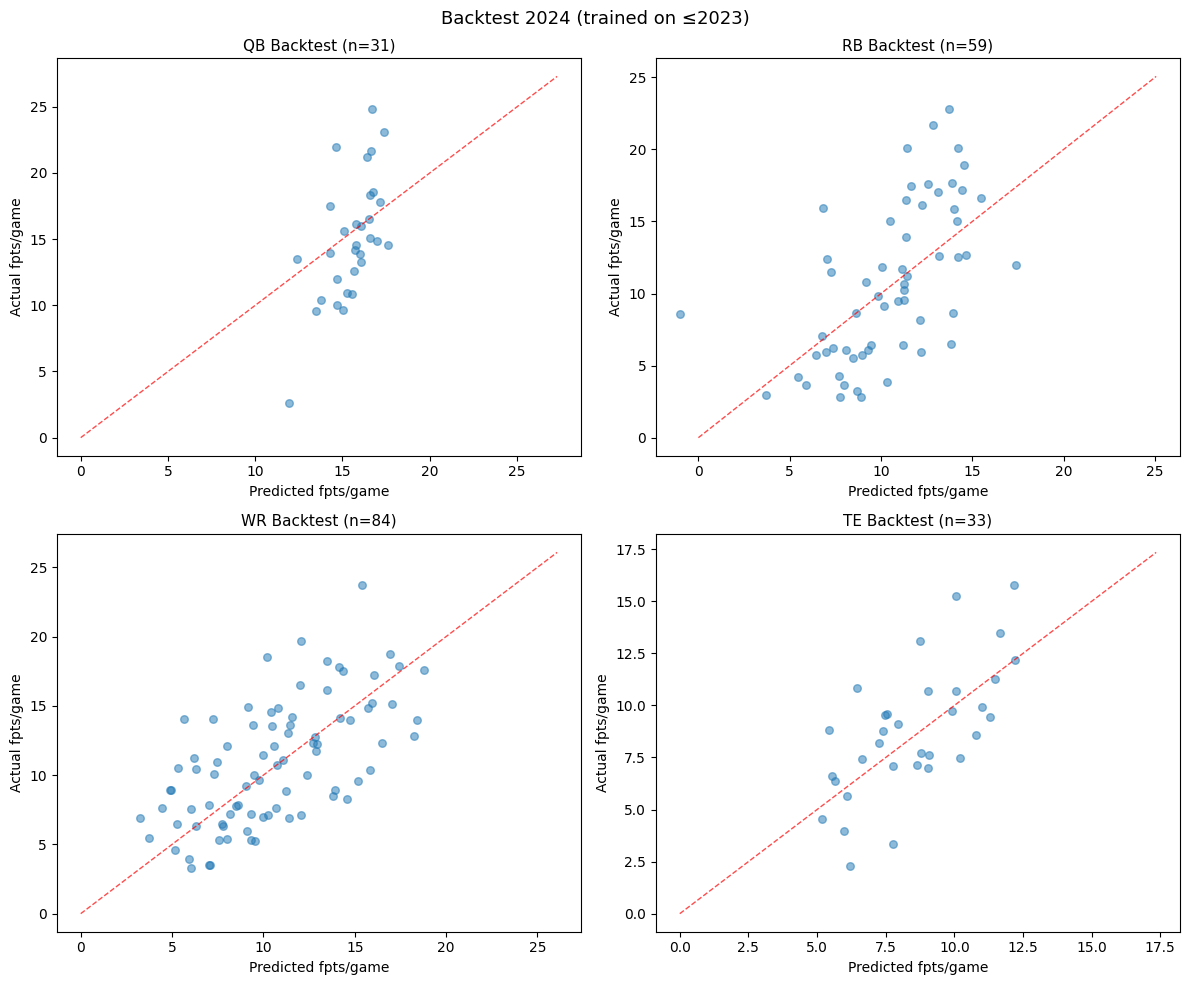

In [8]:
# Scatter: predicted vs. actual for backtest season
test_season = 2023
train_df = yoy[yoy['season'] < test_season]
test_df = yoy[yoy['season'] == test_season]

bt_model = FantasyProjectionModel(age_adjust=False)
bt_model.train(train_df, fit_age=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, pos in zip(axes.flat, POSITIONS):
    pos_test = test_df[test_df['position'] == pos]
    if pos_test.empty or pos not in bt_model._models:
        ax.text(0.5, 0.5, f'{pos}: no data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    features = [f for f in POSITION_FEATURES[pos] if f in pos_test.columns]
    if not features:
        continue
    
    X = pos_test[features].values
    y_actual = pos_test['next_fpts'].values
    y_pred = bt_model._models[pos].predict(X)
    
    valid = ~np.isnan(y_actual)
    ax.scatter(y_pred[valid], y_actual[valid], alpha=0.5, s=30)
    
    # Perfect prediction line
    lim = max(y_actual[valid].max(), y_pred[valid].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Predicted fpts/game')
    ax.set_ylabel('Actual fpts/game')
    ax.set_title(f'{pos} Backtest (n={valid.sum()})', fontsize=11)

plt.suptitle(f'Backtest {test_season+1} (trained on ≤{test_season})', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Aging Curves

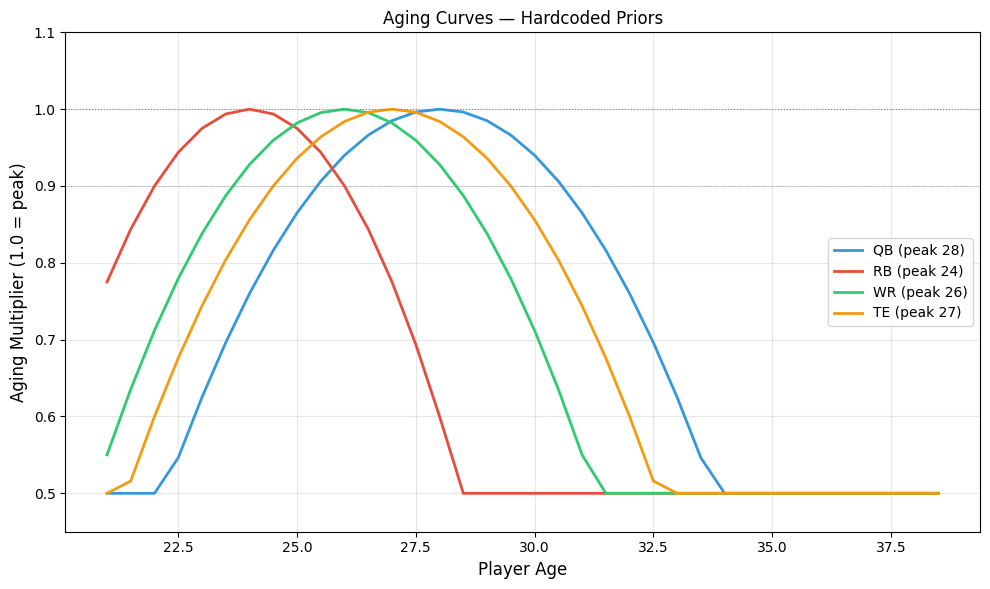

  QB: fitted peak=25.9, decay=0.1000 (prior: peak=28, decay=0.015)
  RB: fitted peak=27.0, decay=0.1000 (prior: peak=24, decay=0.025)
  WR: fitted peak=29.2, decay=0.1000 (prior: peak=26, decay=0.018)
  TE: fitted peak=29.2, decay=0.1000 (prior: peak=27, decay=0.016)


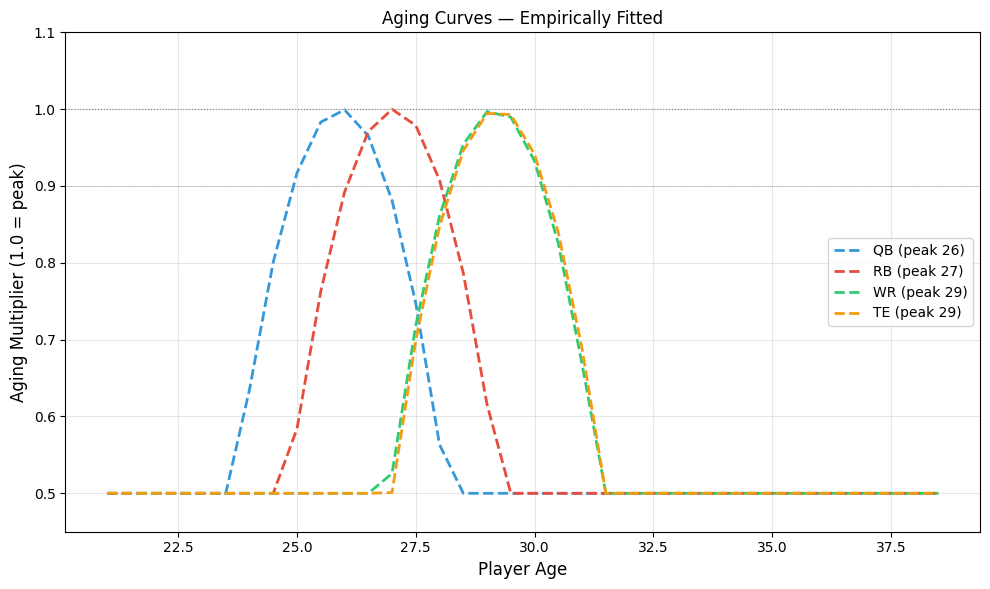

In [9]:
# Hardcoded priors
fig = plot_age_curves()
plt.title('Aging Curves — Hardcoded Priors')
plt.show()

# Try fitting empirical curves
try:
    fitted = fit_age_curves(feature_matrix)
    fig = plot_age_curves(fitted)
    plt.title('Aging Curves — Empirically Fitted')
    plt.show()
except Exception as e:
    print(f'Empirical fitting failed: {e}')

## 6. Residual Analysis

In [10]:
# Who did the model miss most on? Helps identify model blind spots.
for pos in POSITIONS:
    pos_test = test_df[test_df['position'] == pos].copy()
    if pos_test.empty or pos not in bt_model._models:
        continue
    
    features = [f for f in POSITION_FEATURES[pos] if f in pos_test.columns]
    if not features:
        continue
    
    X = pos_test[features].values
    pos_test['predicted'] = bt_model._models[pos].predict(X)
    pos_test['residual'] = pos_test['next_fpts'] - pos_test['predicted']
    pos_test['abs_residual'] = pos_test['residual'].abs()
    
    top_misses = pos_test.nlargest(5, 'abs_residual')[['player_name', 'team', 'age', 'predicted', 'next_fpts', 'residual']]
    top_misses = top_misses.round(2)
    print(f'\n{pos} — Biggest misses:')
    print(top_misses.to_string(index=False))


QB — Biggest misses:
             player_name team  age  predicted  next_fpts  residual
Dorian Thompson-Robinson  CLE 23.0      11.96       2.63     -9.33
           Lamar Jackson  BAL 26.0      16.67      24.82      8.15
              Joe Burrow  CIN 26.0      14.61      21.93      7.32
              Josh Allen  BUF 27.0      17.41      23.07      5.66
         Gardner Minshew  IND 27.0      15.04       9.63     -5.41

RB — Biggest misses:
   player_name team  age  predicted  next_fpts  residual
   Tank Bigsby  JAX 22.0      -1.02       8.60      9.62
   Chase Brown  CIN 23.0       6.81      15.94      9.13
Saquon Barkley  NYG 26.0      13.73      22.79      9.05
  Jahmyr Gibbs  DET 21.0      12.85      21.69      8.84
 Derrick Henry  TEN 29.0      11.43      20.07      8.65

WR — Biggest misses:
     player_name team  age  predicted  next_fpts  residual
  Jauan Jennings   SF 26.0       5.65      14.03      8.38
   Ja'Marr Chase  CIN 23.0      15.40      23.71      8.31
     Tee Higg